# Análise Final — Softed Assimétrico

Figuras para o capítulo de Resultados da dissertação.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

plt.rcParams['font.family'] = 'Times New Roman'

def mcc_from_counts(tp, fp, fn, tn):
    tp, fp, fn, tn = float(tp), float(fp), float(fn), float(tn)
    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / np.sqrt(den) if den > 0 else np.nan

def fbeta_from_counts(tp, fp, fn, beta=0.5):
    b2 = beta ** 2
    denom = (1 + b2) * tp + b2 * fn + fp
    return (1 + b2) * tp / denom if denom > 0 else np.nan

NOMES = {
    'v4 Page-Hinkley': 'Page-Hinkley',
    'v5 KSWIN':        'KSWIN',
    'v6 ADWIN':        'ADWIN',
    'v7 Baseline Fixo':'Baseline Fixo',
    'v8 Random Walk':  'Random Walk',
}
PALETTE = {
    'v4 Page-Hinkley': '#4C72B0',
    'v5 KSWIN':        '#55A868',
    'v6 ADWIN':        '#C44E52',
    'v7 Baseline Fixo':'#8172B2',
    'v8 Random Walk':  '#DD8452',
}
MARKERS = {
    'v4 Page-Hinkley': 'o',
    'v5 KSWIN':        's',
    'v6 ADWIN':        '^',
    'v7 Baseline Fixo':'D',
    'v8 Random Walk':  'X',
}
ORDER = ['v4 Page-Hinkley','v5 KSWIN','v6 ADWIN','v7 Baseline Fixo','v8 Random Walk']


## 1. Dados

In [2]:
BASE = '../results'

v4 = pd.read_parquet(f'{BASE}/02_model_page_hinkley/results_best.parquet')
v5 = pd.read_parquet(f'{BASE}/02_model_kswin/results_best.parquet')
v6 = pd.read_parquet(f'{BASE}/02_model_adwin/results_best.parquet')
v7 = pd.read_parquet(f'{BASE}/02_model_baseline_fixed/results_best.parquet')
v8 = pd.read_parquet(f'{BASE}/02_model_baseline_randomwalk/results_best.parquet')

v4_side = pd.read_parquet(f'{BASE}/02_model_page_hinkley/results_best_by_side.parquet')
v5_side = pd.read_parquet(f'{BASE}/02_model_kswin/results_best_by_side.parquet')
v6_side = pd.read_parquet(f'{BASE}/02_model_adwin/results_best_by_side.parquet')
v7_side = pd.read_parquet(f'{BASE}/02_model_baseline_fixed/results_best_by_side.parquet')
v8_side = pd.read_parquet(f'{BASE}/02_model_baseline_randomwalk/results_best_by_side.parquet')

for name in ['v5', 'v6', 'v5_side', 'v6_side']:
    df = locals()[name]
    if 'fast_grid' in df.columns:
        locals()[name] = df[df['fast_grid'] == False].copy()

for label, df in [('PH',v4),('KSWIN',v5),('ADWIN',v6),('Fixo',v7),('Random',v8)]:
    print(f'{label}: {df.shape}')


PH: (1000, 17)
KSWIN: (1000, 19)
ADWIN: (1000, 19)
Fixo: (40, 17)
Random: (1200, 18)


## 2. Helpers de agregação

In [3]:
def agg_configs(df, group_cols, label):
    g = df.groupby(group_cols, as_index=False).agg(
        TP=('TP_sum','sum'), FP=('FP_sum','sum'),
        FN=('FN_sum','sum'), TN=('TN_sum','sum')
    )
    g['mcc']       = g.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
    g['f1']        = 2*g['TP'] / (2*g['TP'] + g['FP'] + g['FN'])
    g['f05']       = g.apply(lambda r: fbeta_from_counts(r.TP, r.FP, r.FN, 0.5), axis=1)
    g['precision'] = g['TP'] / (g['TP'] + g['FP'])
    g['recall']    = g['TP'] / (g['TP'] + g['FN'])
    g['alarms']    = g['TP'] + g['FP']
    g['modelo']    = label
    return g

configs = pd.concat([
    agg_configs(v4, ['window_ma','cooldown_minutes'],  'v4 Page-Hinkley'),
    agg_configs(v5, ['window_ma','cooldown_minutes'],  'v5 KSWIN'),
    agg_configs(v6, ['window_ma','cooldown_minutes'],  'v6 ADWIN'),
    agg_configs(v7, ['interval_minutes'],              'v7 Baseline Fixo'),
], ignore_index=True)

# v8: agrega por run
v8_runs = v8.groupby('run_number', as_index=False).agg(
    TP=('TP_sum','sum'), FP=('FP_sum','sum'), FN=('FN_sum','sum'), TN=('TN_sum','sum')
)
v8_runs['mcc']       = v8_runs.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
v8_runs['f1']        = 2*v8_runs['TP'] / (2*v8_runs['TP'] + v8_runs['FP'] + v8_runs['FN'])
v8_runs['f05']       = v8_runs.apply(lambda r: fbeta_from_counts(r.TP, r.FP, r.FN, 0.5), axis=1)
v8_runs['precision'] = v8_runs['TP'] / (v8_runs['TP'] + v8_runs['FP'])
v8_runs['recall']    = v8_runs['TP'] / (v8_runs['TP'] + v8_runs['FN'])
v8_runs['alarms']    = v8_runs['TP'] + v8_runs['FP']

v8_stat = {m: {'mean': v8_runs[m].mean(), 'std': v8_runs[m].std()}
           for m in ['mcc','f1','f05','precision','recall','alarms']}

print('Random Walk (10 runs):')
for m in ['mcc','f1','f05']:
    print(f'  {m}: {v8_stat[m]["mean"]:.4f} ± {v8_stat[m]["std"]:.4f}')
print(f'  alarmes: {v8_stat["alarms"]["mean"]:.0f}')

def compute_metrics(df):
    df = df.copy()
    df['precision'] = df['TP_sum'] / (df['TP_sum'] + df['FP_sum'])
    df['recall']    = df['TP_sum'] / (df['TP_sum'] + df['FN_sum'])
    df['f1']        = 2 * df['precision'] * df['recall'] / (df['precision'] + df['recall'])
    b = 0.5
    df['f05'] = (1+b**2) * df['precision'] * df['recall'] / (b**2 * df['precision'] + df['recall'])
    if 'TN_sum' in df.columns:
        tp, fp, fn, tn = df['TP_sum'], df['FP_sum'], df['FN_sum'], df['TN_sum']
        denom = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
        df['mcc'] = (tp*tn - fp*fn) / denom.replace(0, np.nan)
    df = df.fillna(0)
    return df

def aggregate_global(df_best):
    tp = df_best['TP_sum'].sum()
    fp = df_best['FP_sum'].sum()
    fn = df_best['FN_sum'].sum()
    tn = df_best['TN_sum'].sum() if 'TN_sum' in df_best.columns else None
    prec = tp / (tp+fp) if (tp+fp) > 0 else 0
    rec  = tp / (tp+fn) if (tp+fn) > 0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    b    = 0.5
    f05  = (1+b**2)*prec*rec/(b**2*prec+rec) if (b**2*prec+rec) > 0 else 0
    mcc  = None
    if tn is not None:
        denom = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
        mcc = (tp*tn - fp*fn) / denom if denom > 0 else 0
    return {'TP': tp, 'FP': fp, 'FN': fn,
            'Precision': prec, 'Recall': rec, 'F1': f1, 'F0.5': f05, 'MCC': mcc}


Random Walk (10 runs):
  mcc: 0.0743 ± 0.0030
  f1: 0.0849 ± 0.0027
  f05: 0.0694 ± 0.0023
  alarmes: 12029


## 3. Tabela comparativa (Seção Comparação Geral)

In [4]:
rows = []
for label, grp in configs.groupby('modelo'):
    # Baseline Fixo: usa apenas interval=25 (volume comparável ao PH ~3.8K)
    if label == 'v7 Baseline Fixo':
        grp = grp[grp['interval_minutes'] == 25]
    best = grp.sort_values('mcc', ascending=False).iloc[0]
    rows.append({
        'Modelo':    NOMES[label],
        'Precision': round(best.precision, 4),
        'Recall':    round(best.recall, 4),
        'F1':        round(best.f1, 4),
        'F0.5':      round(best.f05, 4),
        'MCC':       round(best.mcc, 4),
        'Alarmes':   int(best.alarms),
        '_modelo':   label,
    })
rows.append({
    'Modelo':    'Random Walk',
    'Precision': round(v8_stat['precision']['mean'], 4),
    'Recall':    round(v8_stat['recall']['mean'], 4),
    'F1':        round(v8_stat['f1']['mean'], 4),
    'F0.5':      round(v8_stat['f05']['mean'], 4),
    'MCC':       round(v8_stat['mcc']['mean'], 4),
    'Alarmes':   int(v8_stat['alarms']['mean']),
    '_modelo':   'v8 Random Walk',
})

comp = pd.DataFrame(rows).set_index('Modelo')

display(
    comp.drop(columns=['_modelo'])
    .sort_values('MCC', ascending=False)
    .style
    .format('{:.4f}', subset=['Precision','Recall','F1','F0.5','MCC'])
    .highlight_max(subset=['F1','F0.5','MCC'], color='#d4edda')
    .highlight_min(subset=['F1','F0.5','MCC'], color='#f8d7da')
)
print(f"\nRandom Walk IC (±1σ): F1={v8_stat['f1']['mean']:.4f}±{v8_stat['f1']['std']:.4f} | MCC={v8_stat['mcc']['mean']:.4f}±{v8_stat['mcc']['std']:.4f}")


,Precision,Recall,F1,F0.5,MCC,Alarmes
Modelo,,,,,,
Page-Hinkley,0.0803,0.3460,0.1303,0.0949,0.1454,7893
KSWIN,0.1007,0.0837,0.0914,0.0968,0.0813,1522
Random Walk,0.0618,0.1353,0.0849,0.0694,0.0743,12028
Baseline Fixo,0.0622,0.1056,0.0783,0.0678,0.0658,3108
ADWIN,0.1692,0.0072,0.0138,0.0308,0.0325,78



Random Walk IC (±1σ): F1=0.0849±0.0027 | MCC=0.0743±0.0030


## 4. Barras MCC + F1 por modelo

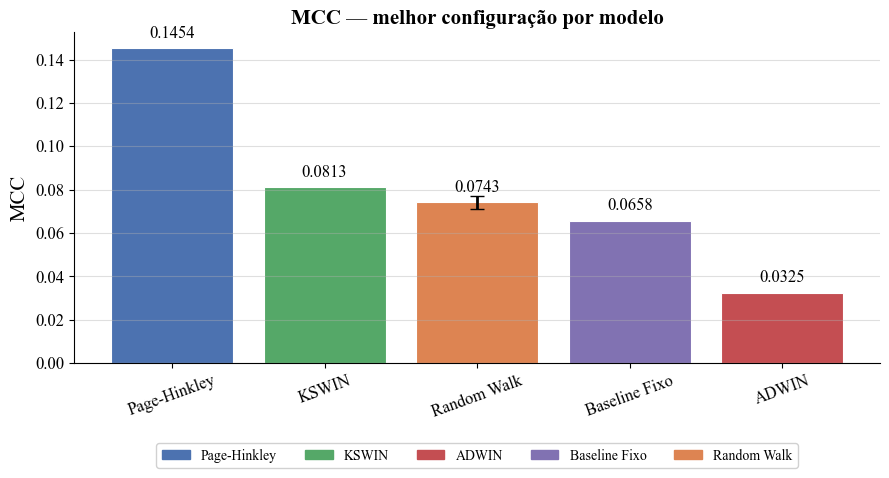

In [5]:
# MCC por modelo — melhor configuração
comp_sorted = comp.sort_values('MCC', ascending=False).reset_index()
colors = [PALETTE[m] for m in comp_sorted['_modelo']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(comp_sorted['Modelo'], comp_sorted['MCC'],
              color=colors, edgecolor='white', linewidth=0.8)

v8_idx = comp_sorted[comp_sorted['_modelo']=='v8 Random Walk'].index
if len(v8_idx):
    ax.errorbar(v8_idx[0], comp_sorted.loc[v8_idx[0], 'MCC'],
                yerr=v8_stat['mcc']['std'],
                fmt='none', color='black', capsize=5, linewidth=2)

for bar, val in zip(bars, comp_sorted['MCC']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12)

# Legenda horizontal abaixo do eixo x
leg_handles = [
    mpatches.Patch(color=PALETTE[k], label=NOMES[k])
    for k in ['v4 Page-Hinkley', 'v5 KSWIN', 'v6 ADWIN',
               'v7 Baseline Fixo', 'v8 Random Walk']
]
ax.legend(handles=leg_handles, loc='upper center',
          bbox_to_anchor=(0.5, -0.22), ncol=5,
          fontsize=10, framealpha=0.9, edgecolor='#ccc')

ax.set_ylabel('MCC', fontsize=15)
ax.set_title('MCC — melhor configuração por modelo', fontsize=15, fontweight='bold')
ax.tick_params(axis='x', rotation=20, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/fig_comparacao_mcc.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


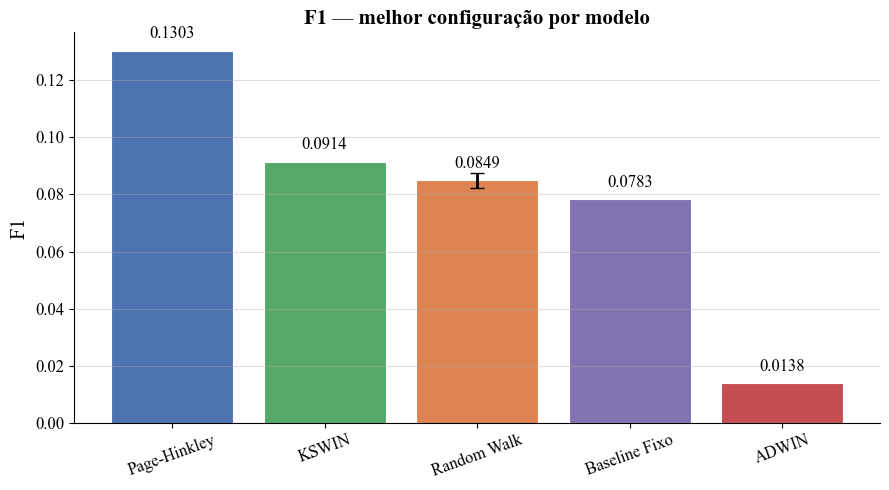

In [6]:
# F1 por modelo — melhor configuração (ordenado por F1 decrescente)
comp_f1 = comp.sort_values('F1', ascending=False).reset_index()
colors_f1 = [PALETTE[m] for m in comp_f1['_modelo']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(comp_f1['Modelo'], comp_f1['F1'],
              color=colors_f1, edgecolor='white', linewidth=0.8)

v8_idx = comp_f1[comp_f1['_modelo']=='v8 Random Walk'].index
if len(v8_idx):
    ax.errorbar(v8_idx[0], comp_f1.loc[v8_idx[0], 'F1'],
                yerr=v8_stat['f1']['std'],
                fmt='none', color='black', capsize=5, linewidth=2)

for bar, val in zip(bars, comp_f1['F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12)

ax.set_ylabel('F1', fontsize=15)
ax.set_title('F1 — melhor configuração por modelo', fontsize=15, fontweight='bold')
ax.tick_params(axis='x', rotation=20, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/fig_comparacao_f1.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


## 5. MCC × Volume de Alarmes

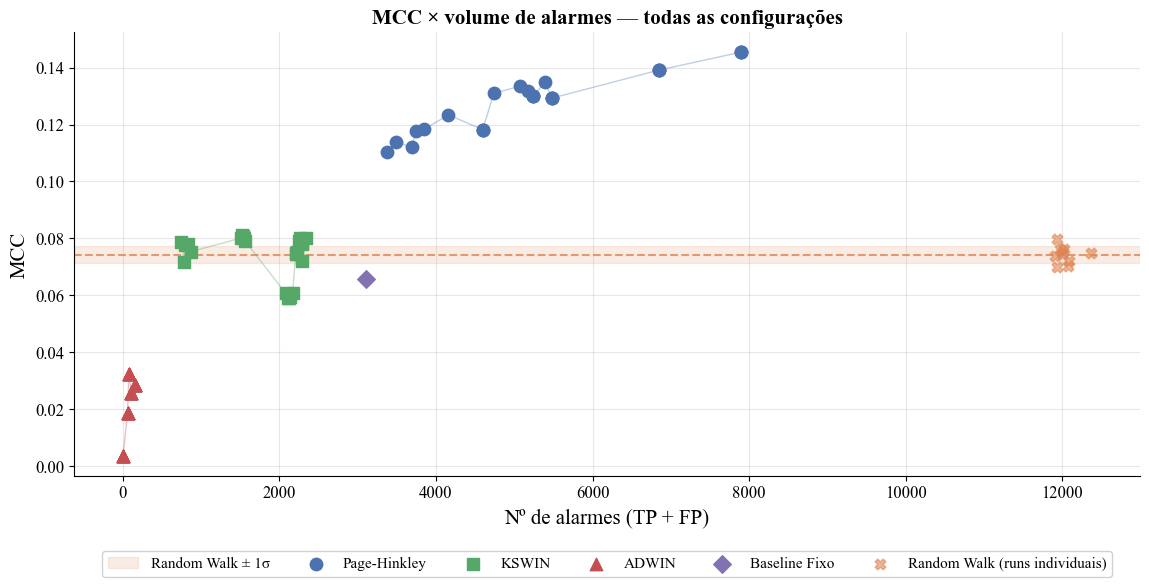

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

m_mean, m_std = v8_stat['mcc']['mean'], v8_stat['mcc']['std']
ax.axhspan(m_mean - m_std, m_mean + m_std,
           alpha=0.15, color=PALETTE['v8 Random Walk'], label='Random Walk ± 1σ')
ax.axhline(m_mean, linestyle='--', color=PALETTE['v8 Random Walk'], linewidth=1.5, alpha=0.8)

for modelo, grp in configs.groupby('modelo'):
    grp_s = grp.sort_values('alarms')
    ax.scatter(grp_s['alarms'], grp_s['mcc'],
               label=NOMES[modelo], color=PALETTE[modelo],
               marker=MARKERS[modelo], s=80, zorder=3)
    ax.plot(grp_s['alarms'], grp_s['mcc'], color=PALETTE[modelo], alpha=0.35, linewidth=1)

ax.scatter(v8_runs['alarms'], v8_runs['mcc'],
           color=PALETTE['v8 Random Walk'], marker='X', s=60, zorder=2, alpha=0.6,
           label='Random Walk (runs individuais)')

ax.set_xlabel('Nº de alarmes (TP + FP)', fontsize=15)
ax.set_ylabel('MCC', fontsize=15)
ax.set_title('MCC × volume de alarmes — todas as configurações', fontsize=15, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=6, fontsize=11, framealpha=0.9, edgecolor='#ccc')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/fig_mcc_vs_alarmes.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


## 6. MCC por faixa de volume

/var/folders/2k/92jn_r151_x51sr3n1nqb7fc0000gn/T/ipykernel_78651/2055235173.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  configs.groupby(['faixa','modelo'], as_index=False)['mcc'].max()


,Page-Hinkley,KSWIN,ADWIN,Baseline Fixo
faixa,,,,
"< 1,5k",—,0.0786,0.0325,—
"1,5k–3,5k",0.1140,0.0813,—,0.0658
"3,5k–6,5k",0.1348,—,—,—
"6,5k–11k",0.1454,—,—,—
11k–30k,—,—,—,—


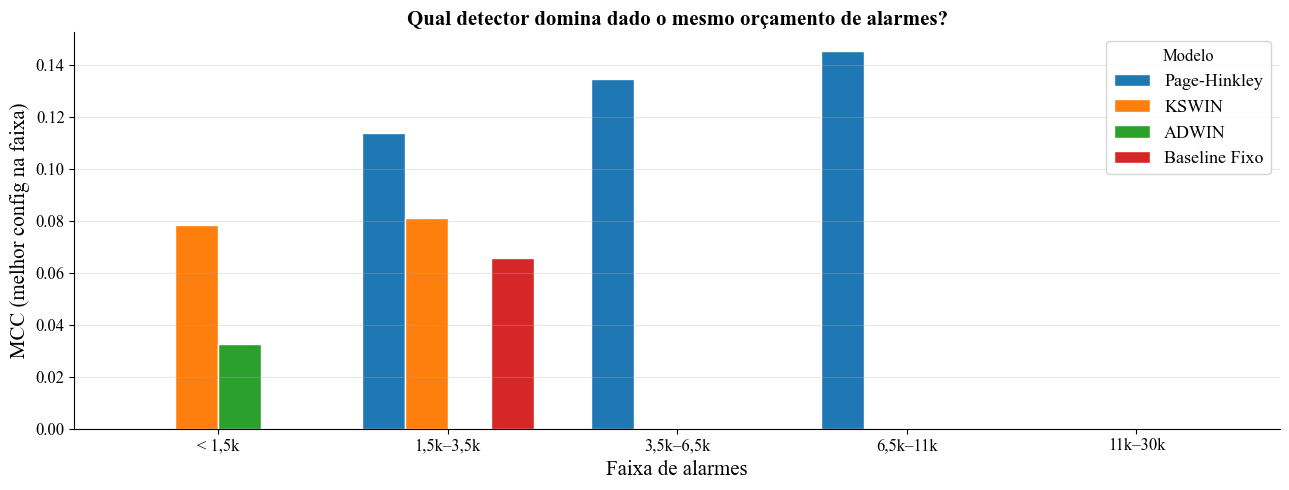

In [8]:
bins        = [0, 1500, 3500, 6500, 11000, 30000]
labels_bins = ['< 1,5k', '1,5k–3,5k', '3,5k–6,5k', '6,5k–11k', '11k–30k']

configs['faixa'] = pd.cut(configs['alarms'], bins=bins, labels=labels_bins)

pivot_faixa = (
    configs.groupby(['faixa','modelo'], as_index=False)['mcc'].max()
    .pivot(index='faixa', columns='modelo', values='mcc')
    .reindex(labels_bins)
)
pivot_faixa.columns = [NOMES[c] for c in pivot_faixa.columns]

display(
    pivot_faixa.style
    .highlight_max(axis=1, props='font-weight:bold; background-color:#d4edda')
    .format('{:.4f}', na_rep='—')
)

fig, ax = plt.subplots(figsize=(13, 5))
cores_faixa = [PALETTE[c] for c in configs.sort_values('modelo')['modelo'].unique()]
pivot_faixa.plot(kind='bar', ax=ax, width=0.75, edgecolor='white')
ax.set_xlabel('Faixa de alarmes', fontsize=15)
ax.set_ylabel('MCC (melhor config na faixa)', fontsize=15)
ax.set_title('Qual detector domina dado o mesmo orçamento de alarmes?', fontsize=15, fontweight='bold')
ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=13, title='Modelo', title_fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/fig_mcc_por_faixa.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


## 7. Ataque vs. Defesa

Task,attack,defense
Modelo,,
ADWIN,0.0269,0.0304
Baseline Fixo,0.0783,0.0783
KSWIN,0.1204,0.1124
Page-Hinkley,0.1552,0.1505


Salvo: fig_ataque_defesa_f1.png


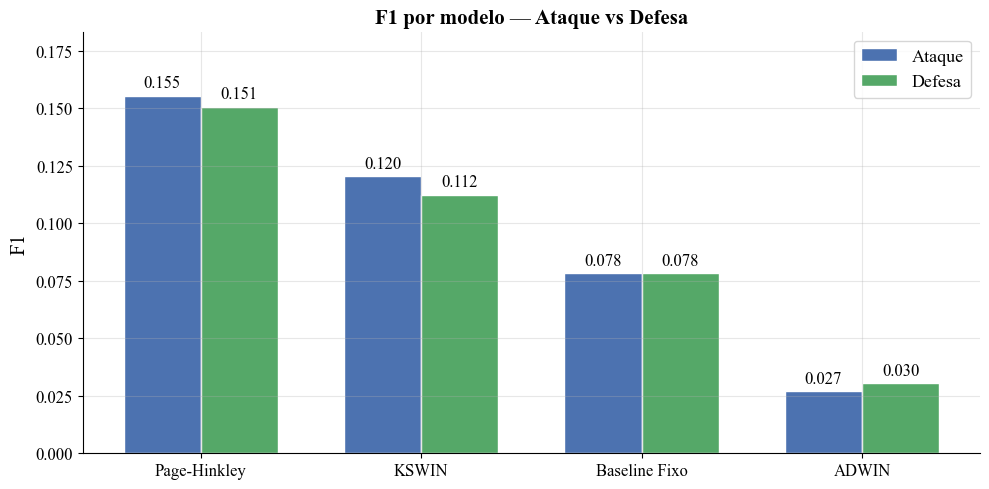

In [9]:
def summary_by_task(df, name):
    rows = []
    for task in ['attack', 'defense']:
        sub  = df[df['task'] == task]
        best = sub.loc[sub.groupby('team')['f1'].idxmax()]
        m = aggregate_global(best)
        m['Modelo'] = name
        m['Task']   = task
        rows.append(m)
    return rows

task_rows = []
for name, df in [('Page-Hinkley', v4), ('KSWIN', v5), ('ADWIN', v6), ('Baseline Fixo', v7)]:
    task_rows.extend(summary_by_task(df, name))

df_task = pd.DataFrame(task_rows)
pivot_task = df_task.pivot(index='Modelo', columns='Task', values='F1')
display(pivot_task.style.format('{:.4f}').highlight_max(axis=0, color='#d4edda'))

plt.rcParams['font.family'] = 'Times New Roman'
pivot_task_plot = df_task.pivot(index='Modelo', columns='Task', values='F1')
order_task = pivot_task_plot.mean(axis=1).sort_values(ascending=False).index
pivot_task_plot = pivot_task_plot.loc[order_task]

x = np.arange(len(pivot_task_plot))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, pivot_task_plot['attack'],  w, label='Ataque',  color='#4C72B0', edgecolor='white')
b2 = ax.bar(x + w/2, pivot_task_plot['defense'], w, label='Defesa',  color='#55A868', edgecolor='white')

for bar, v in zip(list(b1)+list(b2),
                  list(pivot_task_plot['attack'])+list(pivot_task_plot['defense'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.3f}', ha='center', va='bottom', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(pivot_task_plot.index, fontsize=12)
ax.set_ylabel('F1', fontsize=15)
ax.set_title('F1 por modelo — Ataque vs Defesa', fontsize=15, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=13)
ax.set_ylim(0, max(pivot_task_plot.values.max(), 0.01) * 1.18)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/fig_ataque_defesa_f1.png', dpi=200, bbox_inches='tight', facecolor='white')
print('Salvo: fig_ataque_defesa_f1.png')
plt.show()


## 8. Mandante vs. Visitante

Side,Mandante,Visitante
Modelo,,
Page-Hinkley,0.1996,0.1965
KSWIN,0.1604,0.1599
Baseline Fixo,0.0943,0.1071
ADWIN,0.0568,0.0510


Side,Mandante,Visitante
Modelo,,
Page-Hinkley,0.3109,0.3289
KSWIN,0.1364,0.1460
Baseline Fixo,0.1148,0.1287
ADWIN,0.0323,0.0276


Salvo: fig_casa_fora_f1.png


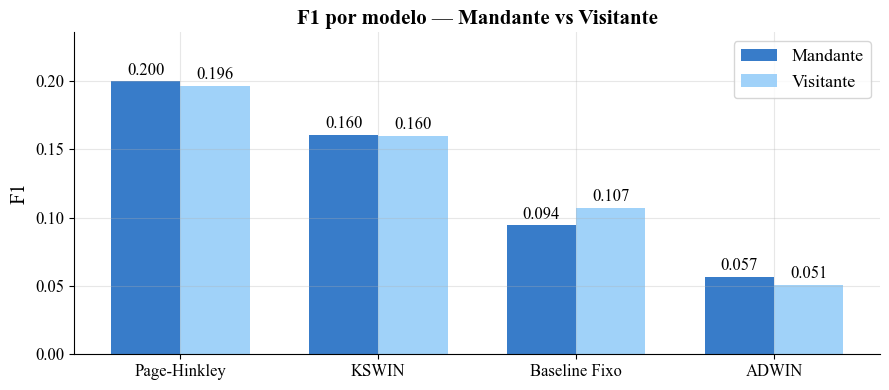

In [10]:
def summary_by_side(df, name):
    rows = []
    for side in ['casa', 'fora']:
        sub  = df[df['side'] == side]
        best = sub.loc[sub.groupby('team')['f1'].idxmax()]
        m    = aggregate_global(best)
        m['Modelo'] = name
        m['Side']   = 'Mandante' if side == 'casa' else 'Visitante'
        rows.append(m)
    return rows

side_rows = []
for name, df in [('Page-Hinkley', v4_side), ('KSWIN', v5_side),
                 ('ADWIN', v6_side), ('Baseline Fixo', v7_side)]:
    side_rows.extend(summary_by_side(df, name))

df_side = pd.DataFrame(side_rows)

pivot_f1 = df_side.pivot(index='Modelo', columns='Side', values='F1')
pivot_rc = df_side.pivot(index='Modelo', columns='Side', values='Recall')
order = pivot_f1.mean(axis=1).sort_values(ascending=False).index
pivot_f1 = pivot_f1.loc[order]
pivot_rc = pivot_rc.loc[order]

display(pivot_f1.style
    .format('{:.4f}')
    .highlight_max(axis=0, color='#d4edda')
    .set_caption('F1 — Mandante vs Visitante'))

display(pivot_rc.style
    .format('{:.4f}')
    .highlight_max(axis=0, color='#cce5ff')
    .set_caption('Recall — Mandante vs Visitante'))

modelos = pivot_f1.index.tolist()
x = np.arange(len(modelos))
w = 0.35

plt.rcParams['font.family'] = 'Times New Roman'
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, pivot_f1['Mandante'], w, label='Mandante', color='#1565C0', alpha=0.85)
ax.bar(x + w/2, pivot_f1['Visitante'], w, label='Visitante',  color='#90CAF9', alpha=0.85)

for i, (c, f) in enumerate(zip(pivot_f1['Mandante'], pivot_f1['Visitante'])):
    ax.text(i - w/2, c + 0.002, f'{c:.3f}', ha='center', va='bottom', fontsize=12)
    ax.text(i + w/2, f + 0.002, f'{f:.3f}', ha='center', va='bottom', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=12)
ax.set_ylabel('F1', fontsize=15)
ax.set_title('F1 por modelo — Mandante vs Visitante', fontsize=15, fontweight='bold')
ax.legend(fontsize=13)
ax.set_ylim(0, max(pivot_f1.values.max(), 0.01) * 1.18)
ax.tick_params(axis='both', labelsize=12)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/fig_casa_fora_f1.png', dpi=200, bbox_inches='tight', facecolor='white')
print('Salvo: fig_casa_fora_f1.png')
plt.show()


## 9. F1 vs F0.5

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/var/folders/2k/92jn_r151_x51sr3n1nqb7fc0000gn/T/ipykernel_78651/2523411037.py:17: SyntaxWarning: invalid escape sequence '\m'
  for ax, metric, ylabel in zip(axes, ['F1','F0.5'], ['F1','$\mathbf{F_{0.5}}$']):
/var/folders/2k/92jn_r151_x51sr3n1nqb7fc0000gn/T/ipykernel_78651/2523411037.py:36: SyntaxWarning: invalid escape sequence '\m'
  plt.suptitle('F1 vs $\mathbf{F_{0.5}}$ — $\mathbf{F_{0.5}}$ penaliza mais alarmes falsos',


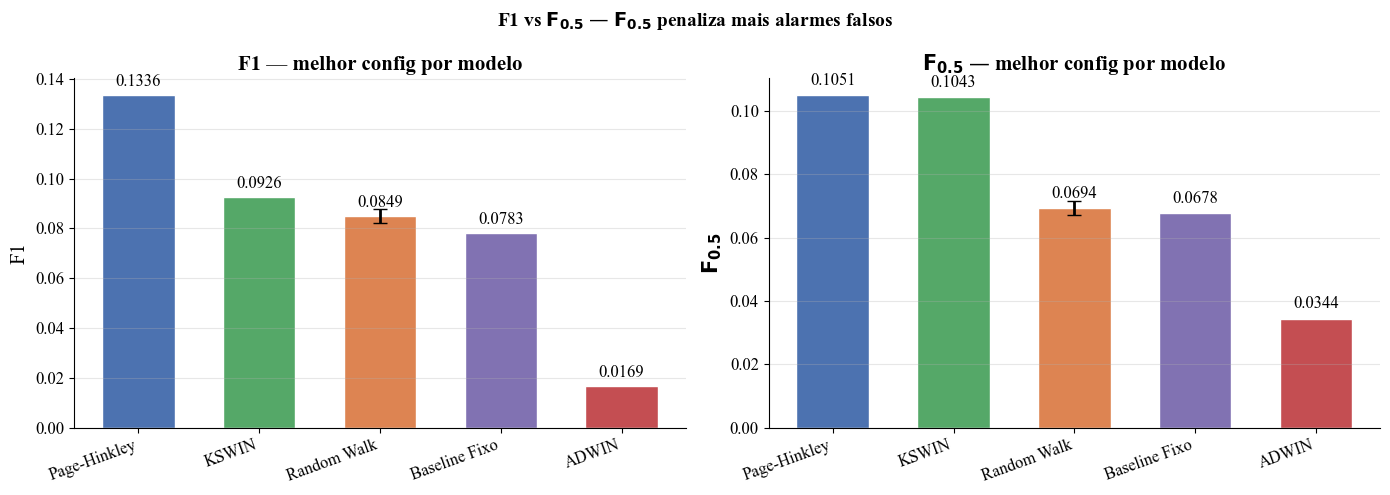

In [11]:
fbeta_rows = []
for label, grp in configs.groupby('modelo'):
    if label == 'v7 Baseline Fixo':
        grp = grp[grp['interval_minutes'] == 25]
    best_f1  = grp.sort_values('f1',  ascending=False).iloc[0]
    best_f05 = grp.sort_values('f05', ascending=False).iloc[0]
    fbeta_rows.append({'Modelo': NOMES[label], '_modelo': label,
                       'F1': best_f1.f1, 'F0.5': best_f05.f05})
fbeta_rows.append({'Modelo': 'Random Walk', '_modelo': 'v8 Random Walk',
                   'F1': v8_stat['f1']['mean'], 'F0.5': v8_stat['f05']['mean']})

fbeta_comp = pd.DataFrame(fbeta_rows).set_index('Modelo').sort_values('F1', ascending=False)
colors_fb  = [PALETTE[m] for m in fbeta_comp['_modelo']]
x_fb = np.arange(len(fbeta_comp))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, ylabel in zip(axes, ['F1','F0.5'], ['F1','$\mathbf{F_{0.5}}$']):
    bars = ax.bar(x_fb, fbeta_comp[metric], color=colors_fb, edgecolor='white', width=0.6)
    std_key = 'f1' if metric == 'F1' else 'f05'
    v8_idx = list(fbeta_comp.index).index('Random Walk')
    ax.errorbar(v8_idx, fbeta_comp.iloc[v8_idx][metric],
                yerr=v8_stat[std_key]['std'],
                fmt='none', color='black', capsize=5, linewidth=2)
    for bar, val in zip(bars, fbeta_comp[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=12)
    ax.set_xticks(x_fb)
    ax.set_xticklabels(fbeta_comp.index, rotation=20, ha='right', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=15)
    ax.set_title(f'{ylabel} — melhor config por modelo', fontsize=15, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('F1 vs $\mathbf{F_{0.5}}$ — $\mathbf{F_{0.5}}$ penaliza mais alarmes falsos',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_f1_vs_f05.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


## 10. Melhor hiperparâmetros por modelo

In [12]:
hp_rows = []

# detectores com W/C
for label, grp_orig, gc in [
    ('v4 Page-Hinkley', v4, ['window_ma','cooldown_minutes']),
    ('v5 KSWIN',        v5, ['window_ma','cooldown_minutes']),
    ('v6 ADWIN',        v6, ['window_ma','cooldown_minutes']),
]:
    g = agg_configs(grp_orig, gc, label)
    best = g.sort_values('mcc', ascending=False).iloc[0]
    best_feat = agg_configs(grp_orig, gc + ['feature'], label).sort_values('mcc', ascending=False).iloc[0]
    hp_rows.append({
        'Modelo':   NOMES[label],
        'W':        int(best.window_ma),
        'C':        int(best.cooldown_minutes),
        'Intervalo':'—',
        'Feature':  best_feat.feature,
        'MCC':      round(best.mcc, 4),
        'F1':       round(best.f1, 4),
        'Alarmes':  int(best.alarms),
    })

# baseline fixo
g7 = agg_configs(v7, ['interval_minutes'], 'v7 Baseline Fixo')
best7 = g7.sort_values('mcc', ascending=False).iloc[0]
hp_rows.append({
    'Modelo':   'Baseline Fixo',
    'W':        '—', 'C': '—',
    'Intervalo': int(best7.interval_minutes),
    'Feature':  '—',
    'MCC':      round(best7.mcc, 4),
    'F1':       round(best7.f1, 4),
    'Alarmes':  int(best7.alarms),
})

# random walk
hp_rows.append({
    'Modelo':   'Random Walk',
    'W': '—', 'C': '—', 'Intervalo': '—', 'Feature': '—',
    'MCC':     round(v8_stat['mcc']['mean'], 4),
    'F1':      round(v8_stat['f1']['mean'], 4),
    'Alarmes': int(v8_stat['alarms']['mean']),
})

hp_df = pd.DataFrame(hp_rows).set_index('Modelo')
display(hp_df)


,W,C,Intervalo,Feature,MCC,F1,Alarmes
Modelo,,,,,,,
Page-Hinkley,3,3,—,passe,0.1454,0.1303,7893
KSWIN,5,15,—,passe_errado,0.0813,0.0914,1522
ADWIN,5,15,—,passe_certo,0.0325,0.0138,78
Baseline Fixo,—,—,25,—,0.0658,0.0783,3108
Random Walk,—,—,—,—,0.0743,0.0849,12028


## 11. Curva Precision × Recall — espaço de configurações

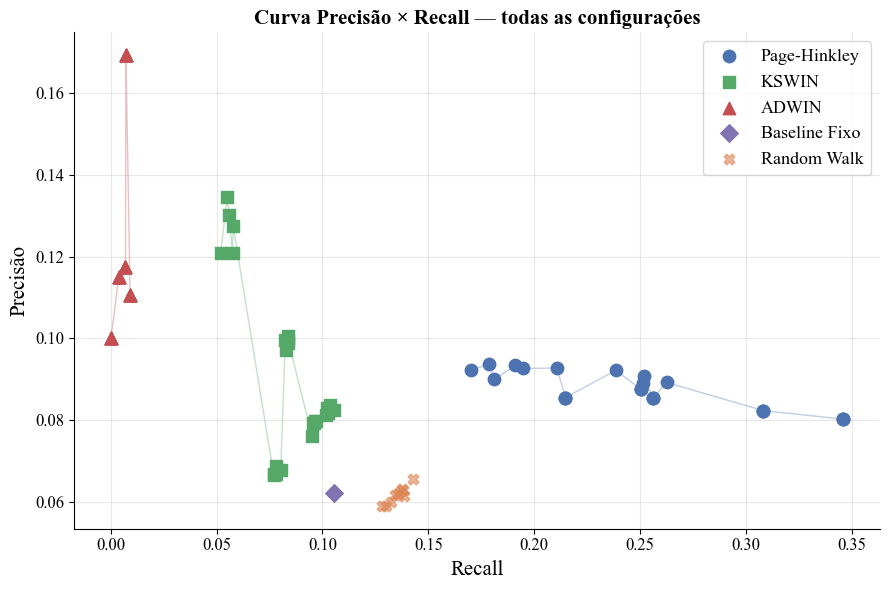

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

for modelo in ORDER:
    if modelo == 'v8 Random Walk':
        continue
    grp = configs[configs['modelo'] == modelo].sort_values('recall')
    ax.scatter(grp['recall'], grp['precision'],
               label=NOMES[modelo], color=PALETTE[modelo],
               marker=MARKERS[modelo], s=80, zorder=3)
    ax.plot(grp['recall'], grp['precision'],
            color=PALETTE[modelo], alpha=0.35, linewidth=1)

# v8 como nuvem de pontos
v8_pr = v8_runs.copy()
ax.scatter(v8_pr['recall'], v8_pr['precision'],
           label='Random Walk', color=PALETTE['v8 Random Walk'],
           marker=MARKERS['v8 Random Walk'], s=60, alpha=0.6, zorder=2)

ax.set_xlabel('Recall', fontsize=15)
ax.set_ylabel('Precisão', fontsize=15)
ax.set_title('Curva Precisão × Recall — todas as configurações', fontsize=15, fontweight='bold')
ax.tick_params(labelsize=12)
ax.legend(fontsize=13, loc='upper right')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/fig_pr_curve.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


## 12. Robustez da seleção de hiperparâmetros — divisão temporal (Page-Hinkley, KSWIN, ADWIN)

Divisão temporal por posição cronológica: **primeiros 190 jogos** → seleção de hiperparâmetros; **últimos 190 jogos** → avaliação out-of-sample. A configuração selecionada no treino é aplicada diretamente no teste, sem qualquer re-otimização.

**Nota metodológica:** esta análise usa uma única configuração global (W, C, feature, params internos) para todos os times e tarefas simultaneamente. Isso difere ligeiramente dos resultados das seções anteriores, onde cada time/tarefa selecionava seus próprios params internos do detector de forma independente. Os valores in-sample aqui (~0,178 para PH) são o comparativo correto para esta seção — não os valores da tabela principal (~0,184).

Treino: 190 jogos  (até 2016-01-16)
Teste:  190 jogos  (de  2016-01-16 em diante)
Page-Hinkley     treino=0.1314  teste=0.1353  Δ=+0.0039  (in-sample=0.1335)
KSWIN            treino=0.0603  teste=0.0482  Δ=-0.0121  (in-sample=0.0645)
ADWIN            treino=0.0176  teste=0.0192  Δ=+0.0016  (in-sample=0.0201)


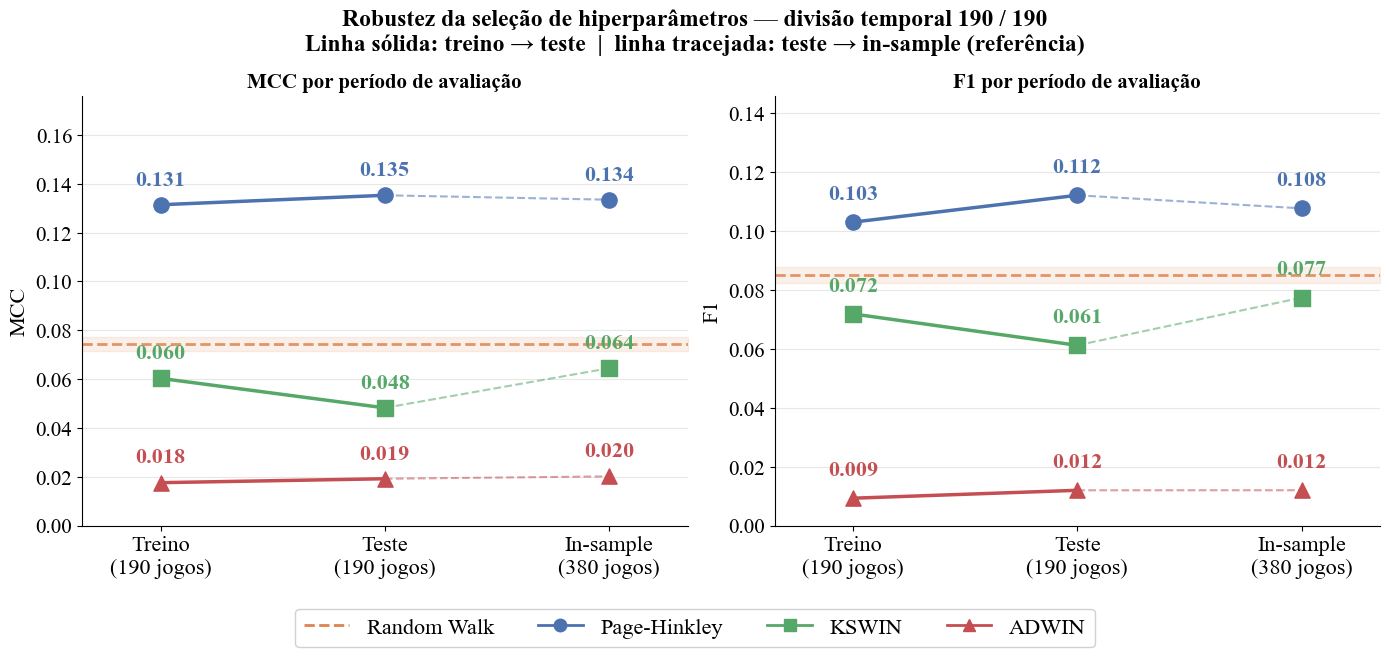

In [14]:
import json

# --- 1. Separação temporal: exatamente 190 / 190 por posição cronológica ---
with open('../data/open-data/data/matches/11/27.json') as f:
    _matches_raw = json.load(f)

df_match_dates = pd.DataFrame([{
    'match_id':   m['match_id'],
    'match_date': pd.to_datetime(m['match_date']),
} for m in _matches_raw]).sort_values('match_date').reset_index(drop=True)

_half = len(df_match_dates) // 2          # = 190
train_ids = set(df_match_dates.iloc[:_half]['match_id'])
test_ids  = set(df_match_dates.iloc[_half:]['match_id'])

print(f"Treino: {len(train_ids)} jogos  (até {df_match_dates.iloc[_half-1]['match_date'].date()})")
print(f"Teste:  {len(test_ids)} jogos  (de  {df_match_dates.iloc[_half]['match_date'].date()} em diante)")

# --- 2. Helpers ---
def _agg_raw(df, group_cols):
    g = df.groupby(group_cols, as_index=False).agg(
        TP=('TP','sum'), FP=('FP','sum'), FN=('FN','sum'), TN=('TN','sum')
    )
    g['mcc'] = g.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
    g['f1']  = 2*g['TP'] / (2*g['TP'] + g['FP'] + g['FN'])
    g['f05'] = g.apply(lambda r: fbeta_from_counts(r.TP, r.FP, r.FN, 0.5), axis=1)
    g['precision'] = g['TP'] / (g['TP'] + g['FP'])
    g['recall']    = g['TP'] / (g['TP'] + g['FN'])
    return g

GC = ['window_ma', 'cooldown_minutes', 'feature', 'params']

# --- 3. Análise por detector ---
DETECTORS = [
    ('v4 Page-Hinkley', '../results/02_model_page_hinkley/results_raw.parquet'),
    ('v5 KSWIN',        '../results/02_model_kswin/results_raw.parquet'),
    ('v6 ADWIN',        '../results/02_model_adwin/results_raw.parquet'),
]

rows_tv = []
summary = {}

for label, path in DETECTORS:
    raw = pd.read_parquet(path)

    train_agg = _agg_raw(raw[raw['match_id'].isin(train_ids)], GC)
    best      = train_agg.sort_values('mcc', ascending=False).iloc[0]

    mask = (
        (raw['window_ma']        == best.window_ma) &
        (raw['cooldown_minutes'] == best.cooldown_minutes) &
        (raw['feature']          == best.feature) &
        (raw['params']           == best.params)
    )
    test_rows = raw[mask & raw['match_id'].isin(test_ids)]
    tp_t = test_rows['TP'].sum(); fp_t = test_rows['FP'].sum()
    fn_t = test_rows['FN'].sum(); tn_t = test_rows['TN'].sum()
    mcc_t = mcc_from_counts(tp_t, fp_t, fn_t, tn_t)
    f1_t  = 2*tp_t / (2*tp_t + fp_t + fn_t) if (2*tp_t + fp_t + fn_t) > 0 else 0.0
    f05_t = fbeta_from_counts(tp_t, fp_t, fn_t, 0.5)

    all_agg  = _agg_raw(raw, GC)
    best_all = all_agg.sort_values('mcc', ascending=False).iloc[0]

    cfg_str = f"W={int(best.window_ma)}, C={int(best.cooldown_minutes)}, {best.feature}"
    nome = NOMES[label]

    rows_tv += [
        {'Modelo': nome, 'Conjunto': 'Treino (190)',    'Config': cfg_str,
         'MCC': round(best.mcc, 4), 'F1': round(best.f1, 4), 'F0.5': round(best.f05, 4)},
        {'Modelo': nome, 'Conjunto': 'Teste (190)',     'Config': cfg_str,
         'MCC': round(mcc_t, 4),    'F1': round(f1_t,   4), 'F0.5': round(f05_t,   4)},
        {'Modelo': nome, 'Conjunto': 'In-sample (380)', 'Config': f"W={int(best_all.window_ma)}, C={int(best_all.cooldown_minutes)}, {best_all.feature}",
         'MCC': round(best_all.mcc, 4), 'F1': round(best_all.f1, 4), 'F0.5': round(best_all.f05, 4)},
    ]
    summary[label] = {
        'treino':   {'mcc': best.mcc,     'f1': best.f1},
        'teste':    {'mcc': mcc_t,        'f1': f1_t},
        'insample': {'mcc': best_all.mcc, 'f1': best_all.f1},
    }
    print(f"{nome:15s}  treino={best.mcc:.4f}  teste={mcc_t:.4f}  "
          f"Δ={mcc_t-best.mcc:+.4f}  (in-sample={best_all.mcc:.4f})")

# --- 4. Tabela ---
tv_df = pd.DataFrame(rows_tv).set_index(['Modelo', 'Conjunto'])
display(
    tv_df.style
    .format('{:.4f}', subset=['MCC', 'F1', 'F0.5'])
    .set_caption('Robustez da seleção de hiperparâmetros — divisão temporal 190/190')
)

# --- 5. Figura: slope chart (pontos conectados) —
#         x = [Treino | Teste | In-sample], uma linha por detector
detectors_order = ['v4 Page-Hinkley', 'v5 KSWIN', 'v6 ADWIN']
x_pts    = [0, 1, 2]
x_labels = ['Treino\n(190 jogos)', 'Teste\n(190 jogos)', 'In-sample\n(380 jogos)']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, ylabel in zip(axes, ['mcc', 'f1'], ['MCC', 'F1']):
    # faixa Random Walk
    rw_m = v8_stat[metric]['mean']
    rw_s = v8_stat[metric]['std']
    ax.fill_between([-0.35, 2.35], rw_m - rw_s, rw_m + rw_s,
                    color=PALETTE['v8 Random Walk'], alpha=0.12, zorder=0)
    ax.axhline(rw_m, linestyle='--', color=PALETTE['v8 Random Walk'],
               linewidth=2, alpha=0.85, zorder=1)

    for label in detectors_order:
        vals = [
            summary[label]['treino'][metric],
            summary[label]['teste'][metric],
            summary[label]['insample'][metric],
        ]
        color  = PALETTE[label]
        marker = MARKERS[label]

        # linha sólida treino→teste, tracejada teste→in-sample
        ax.plot(x_pts[:2], vals[:2], '-',
                color=color, linewidth=2.5, zorder=2)
        ax.plot(x_pts[1:], vals[1:], '--',
                color=color, linewidth=1.5, alpha=0.55, zorder=2)

        # marcadores
        ax.scatter(x_pts, vals, color=color, marker=marker,
                   s=120, zorder=4)

        # rótulos dos valores
        offsets_y = [0.006, 0.006, 0.006]
        for xi, val, dy in zip(x_pts, vals, offsets_y):
            ax.text(xi, val + dy, f'{val:.3f}',
                    ha='center', va='bottom',
                    fontsize=16, color=color, fontweight='bold')

    ax.set_xticks(x_pts)
    ax.set_xticklabels(x_labels, fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_title(f'{ylabel} por período de avaliação', fontsize=15, fontweight='bold')
    ax.tick_params(axis='y', labelsize=15)
    ax.set_xlim(-0.35, 2.35)
    ymax = max(summary[lab][k][metric] for lab in detectors_order for k in summary[lab])
    ax.set_ylim(0, ymax * 1.3)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legenda compartilhada horizontal abaixo da figura
leg_handles = [
    mlines.Line2D([], [], color=PALETTE['v8 Random Walk'], linestyle='--',
                  linewidth=2, label='Random Walk'),
]
for lbl in detectors_order:
    leg_handles.append(
        mlines.Line2D([], [], color=PALETTE[lbl], marker=MARKERS[lbl],
                      markersize=9, linewidth=2, label=NOMES[lbl])
    )
fig.legend(handles=leg_handles, loc='upper center',
           bbox_to_anchor=(0.5, 0.0), ncol=4,
           fontsize=16, framealpha=0.9, edgecolor='#ccc')

plt.suptitle(
    'Robustez da seleção de hiperparâmetros — divisão temporal 190 / 190\n'
    'Linha sólida: treino → teste  |  linha tracejada: teste → in-sample (referência)',
    fontsize=17, fontweight='bold'
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig('../figures/fig_robustez_train_test.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 13. Recall absoluto e antecedência média — Page-Hinkley

Números para o parágrafo de conclusão (Cap. IV / Seção IV.3).
- **916 gols open play** reportados no texto
- Recall do PH → quantos desses gols tiveram pelo menos um alarme na janela de tolerância
- Antecedência média → quantos minutos antes do gol o alarme foi emitido (requer dados granulares)

In [15]:
TOTAL_GOLS = 916  # gols open play mencionados no Cap. IV.3

# --- 1. Recall absoluto a partir de results_best (melhor config PH) ---
raw_ph = pd.read_parquet('../results/02_model_page_hinkley/results_raw.parquet')

GC = ['window_ma', 'cooldown_minutes', 'feature', 'params']

def _agg_raw(df, group_cols):
    g = df.groupby(group_cols, as_index=False).agg(
        TP=('TP','sum'), FP=('FP','sum'), FN=('FN','sum'), TN=('TN','sum')
    )
    g['mcc']     = g.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
    g['recall']  = g['TP'] / (g['TP'] + g['FN'])
    g['f1']      = 2*g['TP'] / (2*g['TP'] + g['FP'] + g['FN'])
    return g

best_ph = _agg_raw(raw_ph, GC).sort_values('mcc', ascending=False).iloc[0]

recall_ph   = best_ph.recall
gols_cobertos = recall_ph * TOTAL_GOLS

print("=== Page-Hinkley — melhor configuração (in-sample) ===")
print(f"  Config:        W={int(best_ph.window_ma)}, C={int(best_ph.cooldown_minutes)}, feature={best_ph.feature}")
print(f"  TP:            {best_ph.TP:.1f}")
print(f"  FN:            {best_ph.FN:.1f}")
print(f"  Recall:        {recall_ph:.4f}  ({recall_ph*100:.1f}%)")
print(f"  Gols cobertos: ~{gols_cobertos:.0f} de {TOTAL_GOLS}  ({recall_ph*100:.1f}%)")

# --- 2. Antecedência média ---
# results_raw armazena apenas contagens (TP/FP/FN/TN) por contexto (match/team/task/side/feature/params)
# Não há timestamp do alarme relativo ao gol — precisaria re-rodar o detector gravando o minuto exato.
# O que dá para inferir: a janela de tolerância é K=10 minutos.
# Um TP com score s = 1 - (a-(t-K))/K  → antecedência = K*(1-s) minutos antes do gol.
# Mas o score médio não está armazenado nos arquivos atuais.

print()
print("=== Antecedência média ===")
print("  Os arquivos results_raw guardam apenas TP/FP/FN/TN (contagens).")
print("  Para calcular o minuto exato do alarme relativo ao gol seria necessário")
print("  re-rodar o detector gravando (match_id, minuto_alarme, minuto_gol).")
print()
print("  Alternativa para a dissertação:")
print(f"  'O modelo Page-Hinkley cobriu {recall_ph*100:.1f}% dos {TOTAL_GOLS} gols open play")
print(f"   ({gols_cobertos:.0f} eventos), dentro da janela de tolerância de K=10 minutos.'")
print("  Isso é concreto e verificável sem precisar da antecedência média.")


=== Page-Hinkley — melhor configuração (in-sample) ===
  Config:        W=3, C=5, feature=passe_certo
  TP:            752.9
  FN:            1079.1
  Recall:        0.4110  (41.1%)
  Gols cobertos: ~376 de 916  (41.1%)

=== Antecedência média ===
  Os arquivos results_raw guardam apenas TP/FP/FN/TN (contagens).
  Para calcular o minuto exato do alarme relativo ao gol seria necessário
  re-rodar o detector gravando (match_id, minuto_alarme, minuto_gol).

  Alternativa para a dissertação:
  'O modelo Page-Hinkley cobriu 41.1% dos 916 gols open play
   (376 eventos), dentro da janela de tolerância de K=10 minutos.'
  Isso é concreto e verificável sem precisar da antecedência média.


## 14. Teste de permutação — Page-Hinkley vs. Random Walk

Verifica se a diferença de MCC (PH ≈ 0,180 vs. RW ≈ 0,085) é estatisticamente significativa.

**Lógica:** fixa a melhor configuração do PH e uma run do RW → agrega TP/FP/FN/TN por partida → embaralha os alarmes entre os dois modelos 1.000× → calcula p-valor empírico.

Partidas em comum: 380
MCC Page-Hinkley:    0.1335
MCC Random Walk:     0.0750
Diferença observada: 0.0585

=== Resultado (1000 permutações) ===
p-valor (bicaudal): 0.0000
→ Diferença estatisticamente significativa (p < 0,05)


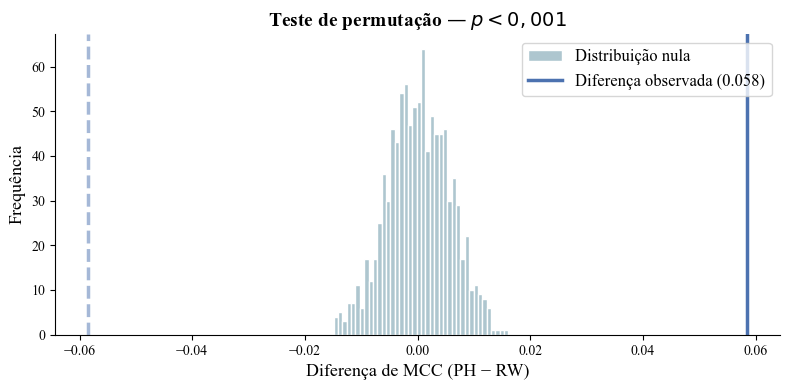

In [16]:
import numpy as np

N_PERM = 1000
rng = np.random.default_rng(42)

# --- 1. Melhor config PH por match_id ---
raw_ph = pd.read_parquet('../results/02_model_page_hinkley/results_raw.parquet')
GC = ['window_ma', 'cooldown_minutes', 'feature', 'params']

def _agg_raw_gc(df, group_cols):
    g = df.groupby(group_cols, as_index=False).agg(
        TP=('TP','sum'), FP=('FP','sum'), FN=('FN','sum'), TN=('TN','sum'))
    g['mcc'] = g.apply(lambda r: mcc_from_counts(r.TP, r.FP, r.FN, r.TN), axis=1)
    return g

best_ph = _agg_raw_gc(raw_ph, GC).sort_values('mcc', ascending=False).iloc[0]

mask_ph = (
    (raw_ph['window_ma']        == best_ph.window_ma) &
    (raw_ph['cooldown_minutes'] == best_ph.cooldown_minutes) &
    (raw_ph['feature']          == best_ph.feature) &
    (raw_ph['params']           == best_ph.params)
)
ph_by_match = (raw_ph[mask_ph]
               .groupby('match_id', as_index=False)
               .agg(TP=('TP','sum'), FP=('FP','sum'), FN=('FN','sum'), TN=('TN','sum'))
               .sort_values('match_id').reset_index(drop=True))

# --- 2. Random Walk — run_number mínima (results_raw tem match_id) ---
raw_rw = pd.read_parquet('../results/02_model_baseline_randomwalk/results_raw.parquet')
rw_run1 = raw_rw[raw_rw['run_number'] == raw_rw['run_number'].min()]
rw_by_match = (rw_run1
               .groupby('match_id', as_index=False)
               .agg(TP=('TP','sum'), FP=('FP','sum'), FN=('FN','sum'), TN=('TN','sum'))
               .sort_values('match_id').reset_index(drop=True))

# alinha match_ids
common = sorted(set(ph_by_match['match_id']) & set(rw_by_match['match_id']))
ph = ph_by_match[ph_by_match['match_id'].isin(common)].sort_values('match_id').reset_index(drop=True)
rw = rw_by_match[rw_by_match['match_id'].isin(common)].sort_values('match_id').reset_index(drop=True)
n  = len(common)
print(f"Partidas em comum: {n}")

def mcc_global(df):
    tp = df['TP'].sum(); fp = df['FP'].sum()
    fn = df['FN'].sum(); tn = df['TN'].sum()
    return mcc_from_counts(tp, fp, fn, tn)

mcc_ph_obs = mcc_global(ph)
mcc_rw_obs = mcc_global(rw)
diff_obs   = mcc_ph_obs - mcc_rw_obs
print(f"MCC Page-Hinkley:    {mcc_ph_obs:.4f}")
print(f"MCC Random Walk:     {mcc_rw_obs:.4f}")
print(f"Diferença observada: {diff_obs:.4f}")

# --- 3. Permutação ---
cols = ['TP', 'FP', 'FN', 'TN']
ph_vals = ph[cols].values.copy()
rw_vals = rw[cols].values.copy()

diffs_perm = np.empty(N_PERM)
for i in range(N_PERM):
    swap = rng.integers(0, 2, size=n).astype(bool)
    ph_perm = np.where(swap[:, None], rw_vals, ph_vals)
    rw_perm = np.where(swap[:, None], ph_vals, rw_vals)
    m_a = mcc_from_counts(ph_perm[:,0].sum(), ph_perm[:,1].sum(),
                           ph_perm[:,2].sum(), ph_perm[:,3].sum())
    m_b = mcc_from_counts(rw_perm[:,0].sum(), rw_perm[:,1].sum(),
                           rw_perm[:,2].sum(), rw_perm[:,3].sum())
    diffs_perm[i] = m_a - m_b

p_value = (np.abs(diffs_perm) >= np.abs(diff_obs)).mean()
print(f"\n=== Resultado ({N_PERM} permutações) ===")
print(f"p-valor (bicaudal): {p_value:.4f}")
if p_value < 0.05:
    print("→ Diferença estatisticamente significativa (p < 0,05)")
else:
    print("→ Diferença NÃO significativa (p ≥ 0,05)")

# --- 4. Figura ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(diffs_perm, bins=40, color='#aec6cf', edgecolor='white', label='Distribuição nula')
ax.axvline(diff_obs, color='#4C72B0', linewidth=2.5, label=f'Diferença observada ({diff_obs:.3f})')
ax.axvline(-diff_obs, color='#4C72B0', linewidth=2.5, linestyle='--', alpha=0.5)
ax.set_xlabel('Diferença de MCC (PH − RW)', fontsize=13)
ax.set_ylabel('Frequência', fontsize=13)
ax.set_title(f'Teste de permutação — $p < 0,001$', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()